# Gene Similarity

In [1]:
import importlib.metadata as _meta
import sys as _sys
print(f"Python {_sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "numpy", "pandas", "matplotlib", "scipy", "polars"]:
    try:
        print(f"  {_pkg}: {_meta.version(_pkg)}")
    except _meta.PackageNotFoundError:
        pass

import sys
sys.path.insert(0, "..")
import re
import seaborn as sns
import pandas as pd
from numpy import exp
from mir.common import GeneLibrary
from mir.distances import GermlineAligner

Python 3.12.12
  mirpy-lib: 1.1.0
  numpy: 1.26.4
  pandas: 3.0.3
  matplotlib: 3.10.9
  scipy: 1.17.1
  polars: 1.40.1


/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
lib = GeneLibrary.load_default(loci={'TRA', 'TRB'})
print(lib.get_summary())
print(lib.get_loci())

Counter({('human', 'TRA', 'V'): 103, ('human', 'TRB', 'V'): 89, ('human', 'TRA', 'J'): 68, ('human', 'TRB', 'J'): 15, ('human', 'TRB', 'D'): 3})
{'TRB', 'TRA'}


In [3]:
seqs = lib.get_sequences_aa(locus='TRB', gene='V')
print(seqs[0:3])

[('TRBV3-1*02', 'DTAVSQTPKYLVTQMGNDKSIKCEQNLGHDTMYWYKQDSKKFLKIMFSYNNKEIIINETVPNRFSPKSPDKAKLNLHINSLELGDSAVYFCASSQ'), ('TRBV17*01', 'EPGVSQTPRHKVTNMGQEVILRCDPSSGHMFVHWYRQNLRQEMKLLISFQYQNIAVDSGMPKERFTAERPNGTSSTLKIHPAEPRDSAVYLYSSG'), ('TRBV18*01', 'NAGVMQNPRHLVRRRGQEARLRCSPMKGHSHVYWYRQLPEEGLKFMVYLQKENIIDESGMPKERFSAEFPKEGPSILRIQQVVRGDSAAYFCASSP')]


In [4]:
galn = GermlineAligner.from_seqs(seqs)
print(galn.dist)
print(galn.score_norm('TRBV10-1*01', 'TRBV10-1*01'))
print(galn.score_norm('TRBV10-1*01', 'TRBV10-2*01'))

{('TRBV3-1*02', 'TRBV3-1*02'): 503.0, ('TRBV3-1*02', 'TRBV17*01'): 151.0, ('TRBV3-1*02', 'TRBV18*01'): 163.0, ('TRBV3-1*02', 'TRBV16*01'): 168.0, ('TRBV3-1*02', 'TRBV29-1*02'): 84.0, ('TRBV3-1*02', 'TRBV15*03'): 198.0, ('TRBV3-1*02', 'TRBV25-1*01'): 127.0, ('TRBV3-1*02', 'TRBV11-2*02'): 133.0, ('TRBV3-1*02', 'TRBV14*01'): 144.0, ('TRBV3-1*02', 'TRBV23-1*01'): 169.0, ('TRBV3-1*02', 'TRBV12-2*01'): 153.0, ('TRBV3-1*02', 'TRBV10-3*02'): 115.0, ('TRBV3-1*02', 'TRBV15*01'): 196.0, ('TRBV3-1*02', 'TRBV20-1*01'): 76.0, ('TRBV3-1*02', 'TRBV12-5*01'): 190.0, ('TRBV3-1*02', 'TRBV26*01'): 113.0, ('TRBV3-1*02', 'TRBV2*03'): 170.0, ('TRBV3-1*02', 'TRBV12-4*01'): 186.0, ('TRBV3-1*02', 'TRBV10-1*04'): 133.0, ('TRBV3-1*02', 'TRBV24-1*01'): 144.0, ('TRBV3-1*02', 'TRBV11-1*01'): 148.0, ('TRBV3-1*02', 'TRBV15*02'): 196.0, ('TRBV3-1*02', 'TRBV3-1*01'): 477.0, ('TRBV3-1*02', 'TRBV12-1*01'): 123.0, ('TRBV3-1*02', 'TRBV10-2*01'): 144.0, ('TRBV3-1*02', 'TRBV28*01'): 139.0, ('TRBV3-1*02', 'TRBV27*01'): 152.0, 

## New API: `GermlineAligner.from_library` (multi-locus)

Builds all pairwise V/J distances in one call; distances accessed via `gene_dist(locus, g1, g2)`.

In [5]:
# Build multi-locus aligner — computes all pairwise TRB V/J distances at construction time
ga_lib = GermlineAligner.from_library(lib, loci=['TRB'])
print(f'_locus_dist entries: {len(ga_lib._locus_dist)}')

# Self-distance is always 0
print('self-dist TRBV10-1*01:', ga_lib.gene_dist('TRB', 'TRBV10-1*01', 'TRBV10-1*01'))

# Pairwise distance (symmetric)
d12 = ga_lib.gene_dist('TRB', 'TRBV10-1*01', 'TRBV10-2*01')
d21 = ga_lib.gene_dist('TRB', 'TRBV10-2*01', 'TRBV10-1*01')
print(f'TRBV10-1 vs TRBV10-2: {d12:.1f}  (reverse: {d21:.1f})')


_locus_dist entries: 8146
self-dist TRBV10-1*01: 0.0
TRBV10-1 vs TRBV10-2: 227.0  (reverse: 227.0)


In [6]:
# Build a distance matrix for TRB V genes using from_library
v_genes = sorted(set(a for (locus, a, _) in ga_lib._locus_dist if locus == 'TRB' and a.startswith('TRBV')))
import pandas as pd
import numpy as np

# Pivot into a matrix for visualization
rows = []
for g1 in v_genes:
    for g2 in v_genes:
        rows.append((g1, g2, ga_lib.gene_dist('TRB', g1, g2)))
df_lib = pd.DataFrame(rows, columns=['Gene1', 'Gene2', 'Dist'])
df_pivot = df_lib.pivot(index='Gene1', columns='Gene2', values='Dist')
print(f'Distance matrix shape: {df_pivot.shape}')
print(df_pivot.iloc[:5, :5])


Distance matrix shape: (89, 89)
Gene2        TRBV1*01  TRBV10-1*01  TRBV10-1*02  TRBV10-1*04  TRBV10-2*01
Gene1                                                                    
TRBV1*01          0.0        828.0        835.0        835.0        771.0
TRBV10-1*01     828.0          0.0         13.0         27.0        227.0
TRBV10-1*02     835.0         13.0          0.0         14.0        232.0
TRBV10-1*04     835.0         27.0         14.0          0.0        246.0
TRBV10-2*01     771.0        227.0        232.0        246.0          0.0


/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


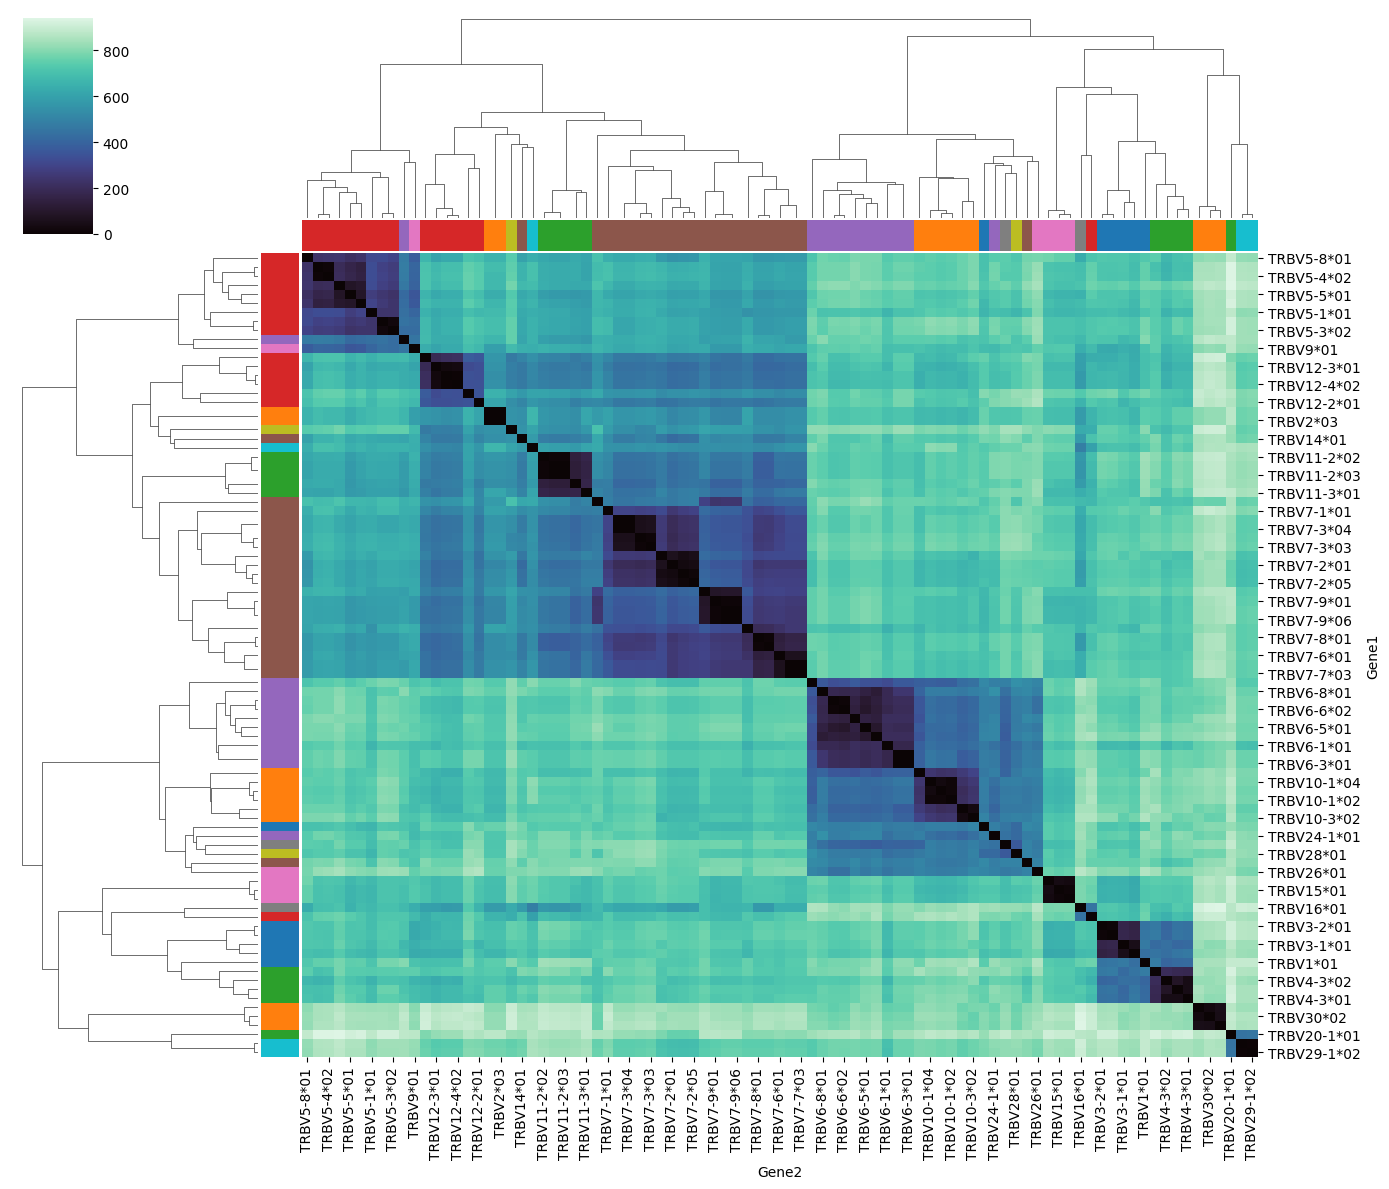

In [7]:
# Clustermap of germline distances (from_library API)
import re
df_sfam2 = pd.DataFrame([(g, re.split('[-\\*]', g)[0]) for g in v_genes],
                        columns=['Gene', 'Fam'])
codes2, uniques2 = pd.factorize(df_sfam2['Fam'])
palette2 = dict(zip(uniques2, sns.color_palette(None, len(uniques2)).as_hex()))
df_sfam2['Col'] = df_sfam2['Fam'].map(palette2)
cols2 = dict(df_sfam2[['Gene', 'Col']].itertuples(index=False))

sns.clustermap(df_pivot, cmap='mako',
               row_colors=df_pivot.index.map(cols2),
               col_colors=df_pivot.index.map(cols2),
               figsize=(14, 12))


In [8]:
df = pd.DataFrame([(g1, g2, s, galn.score_norm(g1, g2)) for ((g1, g2), s) in galn.dist.items()],
                  columns=['Segm1', 'Segm2', 'Score', 'Score_norm'])
print(df)

            Segm1        Segm2  Score  Score_norm
0      TRBV3-1*02   TRBV3-1*02  503.0         0.0
1      TRBV3-1*02    TRBV17*01  151.0      -354.0
2      TRBV3-1*02    TRBV18*01  163.0      -348.0
3      TRBV3-1*02    TRBV16*01  168.0      -345.0
4      TRBV3-1*02  TRBV29-1*02   84.0      -419.0
...           ...          ...    ...         ...
7916  TRBV12-3*01   TRBV7-3*02  281.0      -226.0
7917   TRBV5-4*01   TRBV7-3*02  164.0      -341.0
7918  TRBV11-2*03   TRBV7-3*02  279.0      -220.0
7919   TRBV5-1*01   TRBV7-3*02  171.0      -328.0
7920   TRBV4-3*01   TRBV7-3*02  112.0      -394.0

[7921 rows x 4 columns]


In [9]:
df_sfam = pd.DataFrame([(g, re.split('[-\\*]', g)[0]) for (g, s) in seqs],
                       columns=['Segm', 'Fam'])

codes, uniques = pd.factorize(df_sfam['Fam'])
palette = zip(uniques, sns.color_palette(None, len(uniques)).as_hex())
df_sfam = df_sfam.merge(pd.DataFrame(palette, columns=['Fam', 'Col']))
cols = dict(df_sfam[['Segm', 'Col']].itertuples(index=False))

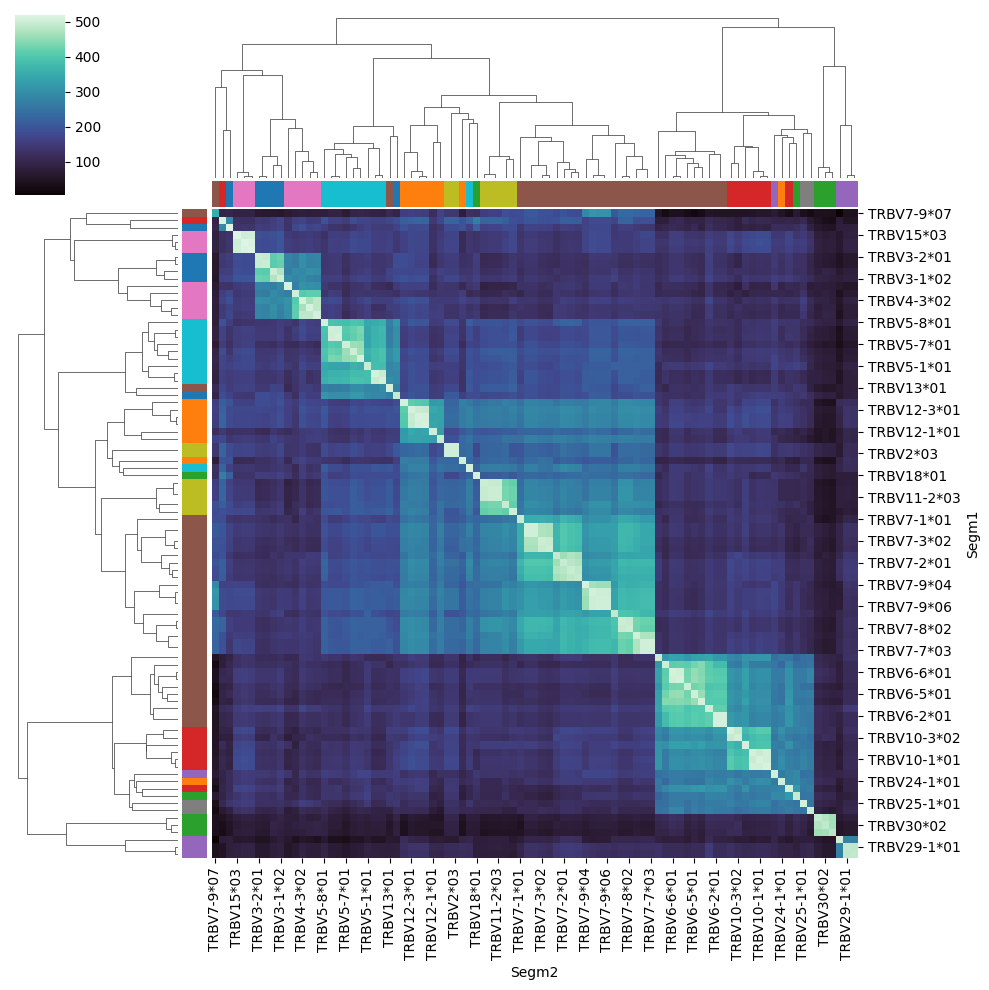

In [10]:
df1 = df.pivot(index='Segm1', columns='Segm2', values='Score')
sns.clustermap(df1, cmap='mako',
               row_colors=df1.index.map(cols),
               col_colors=df1.index.map(cols))

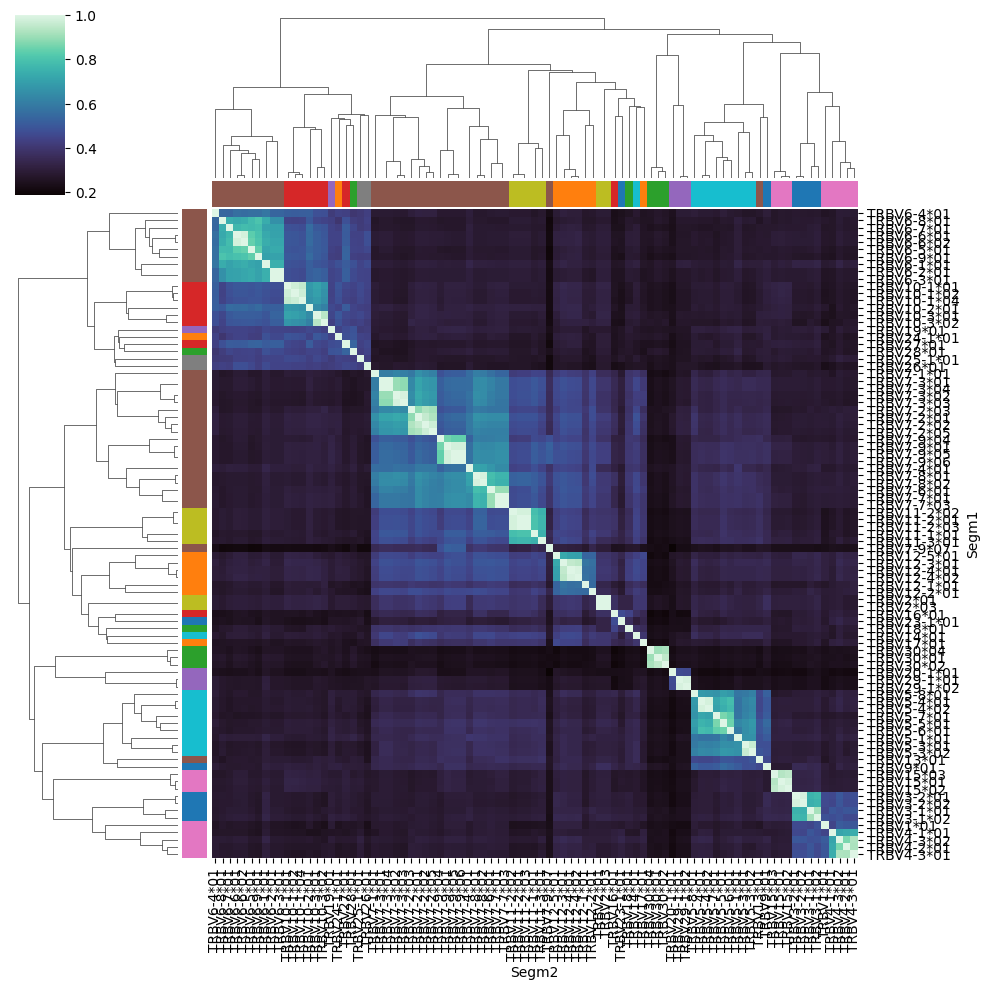

In [11]:
df2 = df.pivot(index='Segm1', columns='Segm2', values='Score_norm')
sns.clustermap(exp(df2/300), cmap='mako',
               row_colors=df2.index.map(cols),
               col_colors=df2.index.map(cols),
               xticklabels=True,
               yticklabels=True)